# 05 — XGBoost как альтернативная модель

## Цель ноутбука

Этот ноутбук нужен для сравнения Prophet с альтернативной ML-моделью. XGBoost не заменяет основной forecast pipeline, а используется как benchmark: мы проверяем, может ли модель на календарных признаках и лагах дать лучшее качество.

## Что передаем в XGBoost

- календарные признаки: месяц, квартал, день недели, неделя года;
- циклические признаки года и недели;
- сезон;
- праздники РФ;
- школьные каникулы;
- длинные выходные;
- лаги `7`, `14`, `28` дней;
- целевую переменную `load_rate`, если доступен `capacity_est`.

## Почему прогноз рекурсивный

Для будущих дат лаги неизвестны. Поэтому XGBoost прогнозирует день 1, добавляет этот прогноз в историю, затем использует его для расчета лагов дня 2 и так далее. Это важное отличие от Prophet и один из рисков XGBoost на длинном горизонте.

## Что сравниваем

Сравнение строится по rolling backtesting на горизонтах 30, 60 и 90 дней. XGBoost может быть сильнее по MAE/RMSE, но для выбора основной модели важнее MAPE, устойчивость и объяснимость.

## Выходы

- `xgboost_model.joblib`
- `forecast_xgboost.parquet`
- `xgboost_backtesting_summary.csv/json`
- `xgboost_vs_prophet_comparison.csv/json`

## 1. Imports and settings

In [1]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

if Path('artifacts_forecasting').exists():
    OUT_DIR = Path('artifacts_forecasting')
    FORECASTING_DIR = Path.cwd()
elif Path('forecasting/artifacts_forecasting').exists():
    OUT_DIR = Path('forecasting') / 'artifacts_forecasting'
    FORECASTING_DIR = Path.cwd() / 'forecasting'
else:
    raise FileNotFoundError('artifacts_forecasting was not found. Run from ml/ or ml/forecasting/.')

if str(FORECASTING_DIR) not in sys.path:
    sys.path.insert(0, str(FORECASTING_DIR))

from holidays_ru import build_holidays_df, get_school_holidays_flag

FORECAST_HORIZONS = (30, 60, 90)
STEP_DAYS = 60
MIN_TRAIN_DAYS = 730
MAX_CUTOFFS = 8
FORECAST_HORIZON = 365
LAGS = (7, 14, 28)
ROLLING_WINDOWS = ()
RANDOM_STATE = 42

XGB_PARAMS = {
    'n_estimators': 300,
    'learning_rate': 0.03,
    'max_depth': 3,
    'min_child_weight': 3,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'reg_lambda': 3.0,
    'reg_alpha': 0.1,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
}

print(json.dumps(XGB_PARAMS, ensure_ascii=False, indent=2))


{
  "n_estimators": 300,
  "learning_rate": 0.03,
  "max_depth": 3,
  "min_child_weight": 3,
  "subsample": 0.85,
  "colsample_bytree": 0.85,
  "reg_lambda": 3.0,
  "reg_alpha": 0.1,
  "objective": "reg:squarederror",
  "eval_metric": "rmse",
  "random_state": 42,
  "n_jobs": -1
}


## 2. Load the same daily series

XGBoost uses the same target logic as Prophet. If `capacity_est` and `load_rate` exist, the model learns `load_rate`, then predictions are converted back to active bookings.

In [2]:
df_daily = pd.read_parquet(OUT_DIR / 'df_daily.parquet')
df_daily['ds'] = pd.to_datetime(df_daily['ds'])
df_daily = df_daily.sort_values('ds').reset_index(drop=True)

TARGET_COL = 'load_rate' if {'load_rate', 'capacity_est'}.issubset(df_daily.columns) else 'y'
START_DATE = df_daily['ds'].min()

print(f'Days: {len(df_daily):,}')
print(f'Date range: {df_daily["ds"].min().date()} - {df_daily["ds"].max().date()}')
print(f'Model target: {TARGET_COL}')
if TARGET_COL == 'load_rate':
    display(df_daily.groupby('year').agg(max_y=('y', 'max'), capacity_est=('capacity_est', 'first'), mean_load_rate=('load_rate', 'mean')).round(3))


Days: 1,399
Date range: 2022-01-01 - 2025-10-30
Model target: load_rate


,max_y,capacity_est,mean_load_rate
year,,,
2022,980,961.0,0.392
2023,992,982.0,0.532
2024,861,824.0,0.509
2025,813,779.0,0.559


## 2.1. Почему XGBoost проверяется как benchmark

ACF из EDA показал высокую инерцию ряда: сильные лаги 7, 14 и 28 дней. Поэтому XGBoost получает календарные признаки и лаговые признаки. Это не отменяет Prophet как основную модель, но дает честную проверку: может ли табличная модель с лагами лучше восстановить короткий горизонт.


,lag,acf
0,1,0.979
1,7,0.837
2,14,0.774
3,28,0.684
4,30,0.666


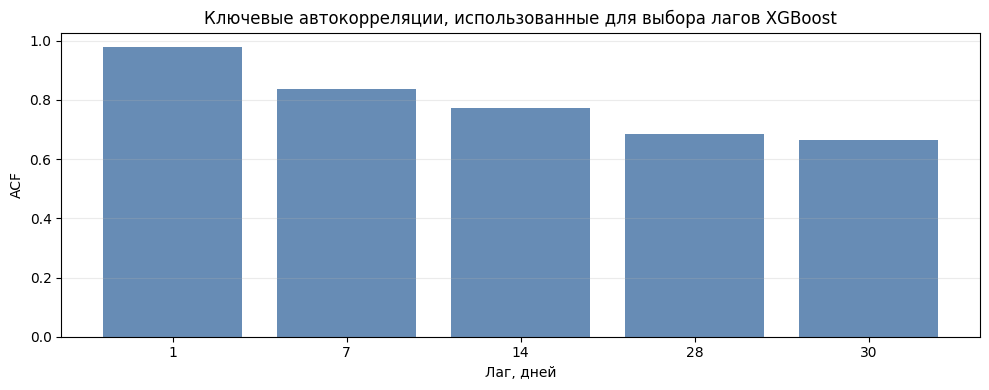

In [3]:
from statsmodels.tsa.stattools import acf

acf_values = acf(df_daily[TARGET_COL].astype(float), nlags=30, fft=True)
acf_summary = pd.DataFrame({
    'lag': [1, 7, 14, 28, 30],
    'acf': [acf_values[lag] for lag in [1, 7, 14, 28, 30]],
})
display(acf_summary.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(acf_summary['lag'].astype(str), acf_summary['acf'], color='#4C78A8', alpha=0.85)
ax.set_title('Ключевые автокорреляции, использованные для выбора лагов XGBoost')
ax.set_xlabel('Лаг, дней')
ax.set_ylabel('ACF')
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig(OUT_DIR / 'xgboost_lag_acf_rationale.png', dpi=160, bbox_inches='tight')
plt.show()


## 3. Feature engineering

Unlike Prophet, XGBoost does not have built-in trend/seasonality components. We explicitly pass calendar features, holiday flags, school holiday flags, long weekend flags and lagged load values.

In [4]:
def mape_pct(y_true: pd.Series, y_pred: pd.Series) -> float:
    mask = y_true != 0
    return float(((y_true[mask] - y_pred[mask]).abs() / y_true[mask]).mean() * 100)


def month_to_season(month: int) -> str:
    if month in (12, 1, 2):
        return 'winter'
    if month in (3, 4, 5):
        return 'spring'
    if month in (6, 7, 8):
        return 'summer'
    return 'autumn'


def is_long_weekend(date_series: pd.Series) -> pd.Series:
    month = date_series.dt.month
    day = date_series.dt.day
    new_year_break = (month == 1) & (day <= 8)
    may_break = (month == 5) & (day <= 10)
    november_break = (month == 11) & (day >= 3) & (day <= 6)
    return (new_year_break | may_break | november_break).astype(int)


def expanded_holiday_dates() -> set[pd.Timestamp]:
    holidays = build_holidays_df(include_official=True, include_school=False)
    dates: set[pd.Timestamp] = set()
    for _, row in holidays.iterrows():
        for offset in range(int(row['lower_window']), int(row['upper_window']) + 1):
            dates.add((row['ds'] + pd.Timedelta(days=offset)).normalize())
    return dates


HOLIDAY_DATES = expanded_holiday_dates()
SCHOOL_HOLIDAY_DATES = set(
    build_holidays_df(include_official=False, include_school=True)['ds'].dt.normalize()
)


def add_calendar_features(df: pd.DataFrame, start_date: pd.Timestamp) -> pd.DataFrame:
    result = df.copy()
    ds = result['ds']
    result['time_idx'] = (ds - start_date).dt.days
    result['month'] = ds.dt.month
    result['quarter'] = ds.dt.quarter
    result['weekday'] = ds.dt.dayofweek
    result['week'] = ds.dt.isocalendar().week.astype(int)
    result['dayofyear'] = ds.dt.dayofyear
    result['is_weekend'] = (result['weekday'] >= 5).astype(int)
    result['is_month_start'] = ds.dt.is_month_start.astype(int)
    result['is_month_end'] = ds.dt.is_month_end.astype(int)
    result['is_holiday_window'] = ds.dt.normalize().isin(HOLIDAY_DATES).astype(int)
    result['is_school_holidays'] = get_school_holidays_flag(ds)
    result['is_long_weekend'] = is_long_weekend(ds)
    result['sin_year'] = np.sin(2 * np.pi * result['dayofyear'] / 365.25)
    result['cos_year'] = np.cos(2 * np.pi * result['dayofyear'] / 365.25)
    result['sin_week'] = np.sin(2 * np.pi * result['weekday'] / 7)
    result['cos_week'] = np.cos(2 * np.pi * result['weekday'] / 7)
    result['season'] = result['month'].map(month_to_season)
    return pd.get_dummies(result, columns=['season'], dtype=int)


def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.sort_values('ds').copy()
    for lag in LAGS:
        result[f'lag_{lag}'] = result['y'].shift(lag)
    for window in ROLLING_WINDOWS:
        shifted = result['y'].shift(1)
        result[f'rolling_mean_{window}'] = shifted.rolling(window).mean()
        result[f'rolling_std_{window}'] = shifted.rolling(window).std()
    return result


## 4. Recursive forecast helpers

For future dates `lag_7`, `lag_14`, `lag_28` are not known. We forecast one day, append the prediction to the history, then forecast the next day.

In [5]:
def calendar_feature_row(ds: pd.Timestamp, start_date: pd.Timestamp) -> dict[str, float | int]:
    dayofyear = int(ds.dayofyear)
    weekday = int(ds.dayofweek)
    season = month_to_season(int(ds.month))
    month = int(ds.month)
    day = int(ds.day)
    long_weekend = (
        (month == 1 and day <= 8)
        or (month == 5 and day <= 10)
        or (month == 11 and 3 <= day <= 6)
    )
    return {
        'time_idx': int((ds - start_date).days),
        'month': int(ds.month),
        'quarter': int(ds.quarter),
        'weekday': weekday,
        'week': int(ds.isocalendar().week),
        'dayofyear': dayofyear,
        'is_weekend': int(weekday >= 5),
        'is_month_start': int(ds.is_month_start),
        'is_month_end': int(ds.is_month_end),
        'is_holiday_window': int(ds.normalize() in HOLIDAY_DATES),
        'is_school_holidays': int(ds.normalize() in SCHOOL_HOLIDAY_DATES),
        'is_long_weekend': int(long_weekend),
        'sin_year': float(np.sin(2 * np.pi * dayofyear / 365.25)),
        'cos_year': float(np.cos(2 * np.pi * dayofyear / 365.25)),
        'sin_week': float(np.sin(2 * np.pi * weekday / 7)),
        'cos_week': float(np.cos(2 * np.pi * weekday / 7)),
        'season_autumn': int(season == 'autumn'),
        'season_spring': int(season == 'spring'),
        'season_summer': int(season == 'summer'),
        'season_winter': int(season == 'winter'),
    }


def recursive_feature_row(values: list[float], ds: pd.Timestamp, start_date: pd.Timestamp) -> dict[str, float | int]:
    row = calendar_feature_row(ds, start_date)
    for lag in LAGS:
        row[f'lag_{lag}'] = values[-lag] if len(values) >= lag else np.nan
    series = pd.Series(values, dtype='float64')
    for window in ROLLING_WINDOWS:
        tail = series.tail(window)
        row[f'rolling_mean_{window}'] = float(tail.mean()) if len(tail) == window else np.nan
        row[f'rolling_std_{window}'] = float(tail.std()) if len(tail) == window else np.nan
    return row


def build_train_frame(history: pd.DataFrame, start_date: pd.Timestamp, target_col: str) -> pd.DataFrame:
    model_history = history[['ds', target_col]].rename(columns={target_col: 'y'})
    features = add_calendar_features(model_history, start_date)
    features = add_lag_features(features)
    return features.dropna().reset_index(drop=True)


def feature_columns(train_frame: pd.DataFrame) -> list[str]:
    return [column for column in train_frame.columns if column not in {'ds', 'y'}]


def fit_xgboost(train: pd.DataFrame, start_date: pd.Timestamp, target_col: str):
    train_frame = build_train_frame(train, start_date, target_col)
    features = feature_columns(train_frame)
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(train_frame[features], train_frame['y'])
    return model, features


def recursive_forecast(model, features: list[str], history: pd.DataFrame, start_date: pd.Timestamp, horizon: int, target_col: str) -> pd.DataFrame:
    working = history[['ds', target_col]].rename(columns={target_col: 'y'}).sort_values('ds').copy()
    values = working['y'].astype(float).tolist()
    current_date = working['ds'].max()
    future_rows = []

    for _ in range(horizon):
        next_date = current_date + pd.Timedelta(days=1)
        row = pd.DataFrame([recursive_feature_row(values, next_date, start_date)])
        row = row.reindex(columns=features, fill_value=0)
        yhat = max(0.0, float(model.predict(row[features])[0]))
        values.append(yhat)
        current_date = next_date
        future_rows.append({'ds': next_date, 'yhat': yhat})

    return pd.DataFrame(future_rows)


## 5. Rolling backtesting

In [6]:
def build_cutoffs(df: pd.DataFrame) -> list[pd.Timestamp]:
    first_cutoff = df['ds'].min() + pd.Timedelta(days=MIN_TRAIN_DAYS)
    last_cutoff = df['ds'].max() - pd.Timedelta(days=max(FORECAST_HORIZONS))
    cutoffs = list(pd.date_range(first_cutoff, last_cutoff, freq=f'{STEP_DAYS}D'))
    return cutoffs[-MAX_CUTOFFS:]


def add_capacity_to_forecast(forecast: pd.DataFrame, history: pd.DataFrame) -> pd.DataFrame:
    result = forecast.copy()
    if TARGET_COL == 'load_rate':
        capacity_by_year = history.groupby(history['ds'].dt.year)['capacity_est'].first().to_dict()
        last_capacity = float(history.sort_values('ds')['capacity_est'].iloc[-1])
        result['capacity_est'] = result['ds'].dt.year.map(capacity_by_year).fillna(last_capacity).astype(float)
        result['yhat_rate'] = result['yhat']
        result['yhat'] = result['yhat_rate'] * result['capacity_est']
    return result


def evaluate_forecast(df: pd.DataFrame, forecast: pd.DataFrame, cutoff: pd.Timestamp) -> list[dict]:
    rows = []
    forecast_abs = add_capacity_to_forecast(forecast, df)
    for horizon in FORECAST_HORIZONS:
        end_date = cutoff + pd.Timedelta(days=horizon)
        columns = ['ds', 'y', TARGET_COL]
        if 'capacity_est' in df.columns:
            columns.append('capacity_est')
        actual = df[(df['ds'] > cutoff) & (df['ds'] <= end_date)][columns]
        eval_df = actual.merge(forecast_abs, on='ds', how='inner')
        if eval_df.empty:
            continue
        eval_df['season'] = eval_df['ds'].dt.month.map(month_to_season)
        row = {
            'cutoff': cutoff.date().isoformat(),
            'horizon_days': horizon,
            'n_days': int(len(eval_df)),
            'mae': round(float(mean_absolute_error(eval_df['y'], eval_df['yhat'])), 2),
            'rmse': round(float(mean_squared_error(eval_df['y'], eval_df['yhat']) ** 0.5), 2),
            'mape_pct': round(mape_pct(eval_df['y'], eval_df['yhat']), 2),
            'season': 'all',
        }
        if TARGET_COL == 'load_rate':
            row['mae_rate'] = round(float(mean_absolute_error(eval_df['load_rate'], eval_df['yhat_rate'])), 4)
        rows.append(row)
    return rows


def summarize(metrics: pd.DataFrame) -> pd.DataFrame:
    return (
        metrics[metrics['season'] == 'all']
        .groupby('horizon_days')
        .agg(
            cutoffs=('cutoff', 'nunique'),
            mae_mean=('mae', 'mean'),
            rmse_mean=('rmse', 'mean'),
            mape_mean=('mape_pct', 'mean'),
            mape_std=('mape_pct', 'std'),
        )
        .round(2)
        .reset_index()
    )

rows = []
cutoffs = build_cutoffs(df_daily)
print(f'Cutoffs: {[d.date().isoformat() for d in cutoffs]}')

for cutoff in cutoffs:
    print(f'Backtesting cutoff: {cutoff.date()}')
    train = df_daily[df_daily['ds'] <= cutoff].copy()
    model, features = fit_xgboost(train, START_DATE, TARGET_COL)
    forecast = recursive_forecast(model, features, train, START_DATE, max(FORECAST_HORIZONS), TARGET_COL)
    rows.extend(evaluate_forecast(df_daily, forecast, cutoff))

xgb_metrics = pd.DataFrame(rows)
xgb_summary = summarize(xgb_metrics)
display(xgb_summary)


Cutoffs: ['2024-04-30', '2024-06-29', '2024-08-28', '2024-10-27', '2024-12-26', '2025-02-24', '2025-04-25', '2025-06-24']
Backtesting cutoff: 2024-04-30
Backtesting cutoff: 2024-06-29
Backtesting cutoff: 2024-08-28
Backtesting cutoff: 2024-10-27
Backtesting cutoff: 2024-12-26
Backtesting cutoff: 2025-02-24
Backtesting cutoff: 2025-04-25
Backtesting cutoff: 2025-06-24


,horizon_days,cutoffs,mae_mean,rmse_mean,mape_mean,mape_std
0,30,8,68.14,83.65,21.98,14.24
1,60,8,66.08,80.30,19.55,11.59
2,90,8,67.34,84.74,20.08,11.35


Backtesting cutoff: 2024-08-28


Backtesting cutoff: 2024-10-27


Backtesting cutoff: 2024-12-26


Backtesting cutoff: 2025-02-24


Backtesting cutoff: 2025-04-25


Backtesting cutoff: 2025-06-24


,horizon_days,cutoffs,mae_mean,rmse_mean,mape_mean,mape_std
0,30,8,68.14,83.65,21.98,14.24
1,60,8,66.08,80.30,19.55,11.59
2,90,8,67.34,84.74,20.08,11.35


## 6. Final XGBoost model and artifacts

Saved: artifacts_forecasting\xgboost_model.joblib
Saved: artifacts_forecasting\forecast_xgboost.parquet
Saved: artifacts_forecasting\xgboost_backtesting_summary.csv


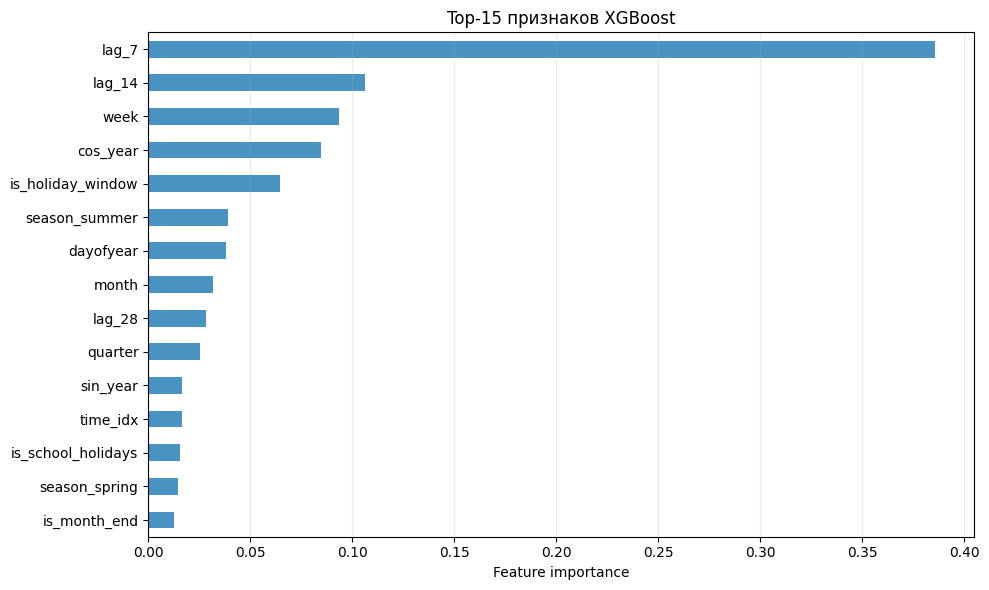

In [7]:
final_model, final_features = fit_xgboost(df_daily, START_DATE, TARGET_COL)
forecast_xgboost = recursive_forecast(final_model, final_features, df_daily, START_DATE, FORECAST_HORIZON, TARGET_COL)
forecast_xgboost = add_capacity_to_forecast(forecast_xgboost, df_daily)

residuals = []
for cutoff in cutoffs:
    train = df_daily[df_daily['ds'] <= cutoff].copy()
    model, features = fit_xgboost(train, START_DATE, TARGET_COL)
    forecast = recursive_forecast(model, features, train, START_DATE, max(FORECAST_HORIZONS), TARGET_COL)
    forecast = add_capacity_to_forecast(forecast, df_daily)
    actual = df_daily[(df_daily['ds'] > cutoff) & (df_daily['ds'] <= cutoff + pd.Timedelta(days=max(FORECAST_HORIZONS)))][['ds', 'y']]
    joined = actual.merge(forecast, on='ds', how='inner')
    residuals.extend((joined['y'] - joined['yhat']).tolist())

residual_std = float(pd.Series(residuals).std()) if residuals else 0.0
forecast_xgboost['yhat_lower'] = (forecast_xgboost['yhat'] - 1.64 * residual_std).clip(lower=0)
forecast_xgboost['yhat_upper'] = forecast_xgboost['yhat'] + 1.64 * residual_std

xgb_payload = {'model': final_model, 'features': final_features, 'params': XGB_PARAMS, 'target': TARGET_COL}
joblib.dump(xgb_payload, OUT_DIR / 'xgboost_model.joblib')
forecast_xgboost.to_parquet(OUT_DIR / 'forecast_xgboost.parquet', index=False)
xgb_metrics.to_csv(OUT_DIR / 'xgboost_backtesting_metrics.csv', index=False, encoding='utf-8-sig')
xgb_summary.to_csv(OUT_DIR / 'xgboost_backtesting_summary.csv', index=False, encoding='utf-8-sig')
with open(OUT_DIR / 'xgboost_backtesting_summary.json', 'w', encoding='utf-8') as f:
    json.dump(xgb_summary.to_dict(orient='records'), f, ensure_ascii=False, indent=2)

print(f'Saved: {OUT_DIR / "xgboost_model.joblib"}')
print(f'Saved: {OUT_DIR / "forecast_xgboost.parquet"}')
print(f'Saved: {OUT_DIR / "xgboost_backtesting_summary.csv"}')


importance = pd.Series(final_model.feature_importances_, index=final_features).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 6))
importance.sort_values().plot(kind='barh', ax=ax, color='#2980b9', alpha=0.85)
ax.set_title('Top-15 признаков XGBoost')
ax.set_xlabel('Feature importance')
ax.grid(True, alpha=0.25, axis='x')
plt.tight_layout()
plt.savefig(OUT_DIR / 'xgboost_feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()


## 7. Compare XGBoost with Prophet

In [8]:
prophet_summary_path = OUT_DIR / 'backtesting_summary.csv'
if prophet_summary_path.exists():
    prophet_summary = pd.read_csv(prophet_summary_path)
    prophet_summary = prophet_summary.rename(columns={
        'mae_mean': 'prophet_mae_mean',
        'rmse_mean': 'prophet_rmse_mean',
        'mape_mean': 'prophet_mape_mean',
        'mape_std': 'prophet_mape_std',
        'cutoffs': 'prophet_cutoffs',
    })
    xgb_for_compare = xgb_summary.rename(columns={
        'mae_mean': 'xgboost_mae_mean',
        'rmse_mean': 'xgboost_rmse_mean',
        'mape_mean': 'xgboost_mape_mean',
        'mape_std': 'xgboost_mape_std',
        'cutoffs': 'xgboost_cutoffs',
    })
    model_compare = prophet_summary.merge(xgb_for_compare, on='horizon_days', how='inner')
    model_compare['mape_delta_xgb_minus_prophet'] = (model_compare['xgboost_mape_mean'] - model_compare['prophet_mape_mean']).round(2)
    model_compare['mae_delta_xgb_minus_prophet'] = (model_compare['xgboost_mae_mean'] - model_compare['prophet_mae_mean']).round(2)
    model_compare['rmse_delta_xgb_minus_prophet'] = (model_compare['xgboost_rmse_mean'] - model_compare['prophet_rmse_mean']).round(2)
    model_compare.to_csv(OUT_DIR / 'xgboost_vs_prophet_comparison.csv', index=False, encoding='utf-8-sig')
    with open(OUT_DIR / 'xgboost_vs_prophet_comparison.json', 'w', encoding='utf-8') as f:
        json.dump(model_compare.to_dict(orient='records'), f, ensure_ascii=False, indent=2)
    display(model_compare)
else:
    model_compare = pd.DataFrame()
    print('Prophet rolling summary was not found. Run Prophet backtesting first if you need horizon-by-horizon comparison.')


,horizon_days,prophet_cutoffs,prophet_mae_mean,prophet_rmse_mean,prophet_mape_mean,prophet_mape_std,xgboost_cutoffs,xgboost_mae_mean,xgboost_rmse_mean,xgboost_mape_mean,xgboost_mape_std,mape_delta_xgb_minus_prophet,mae_delta_xgb_minus_prophet,rmse_delta_xgb_minus_prophet
0,30,8,72.68,90.17,20.50,10.74,8,68.14,83.65,21.98,14.24,1.48,-4.54,-6.52
1,60,8,69.47,86.17,18.76,9.41,8,66.08,80.30,19.55,11.59,0.79,-3.39,-5.87
2,90,8,74.12,93.59,19.64,8.12,8,67.34,84.74,20.08,11.35,0.44,-6.78,-8.85


## 8. Visual comparison of forecasts

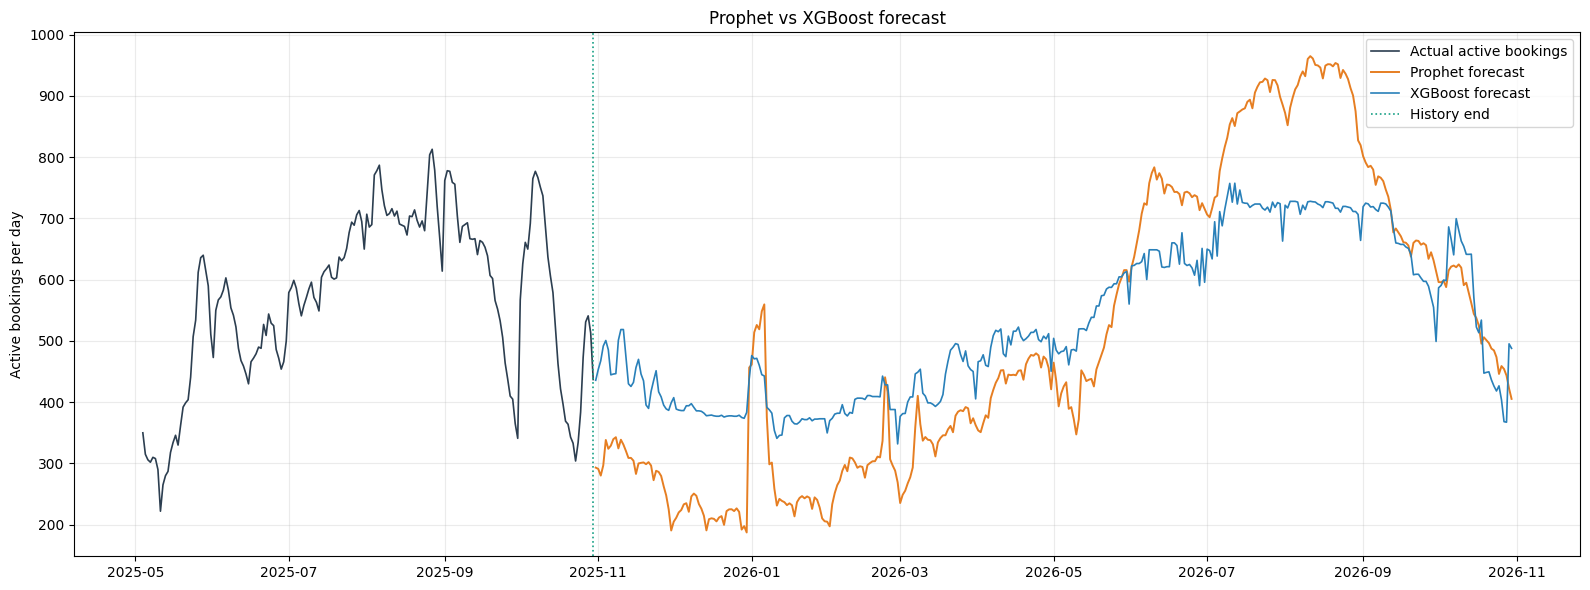

In [9]:
forecast_prophet = pd.read_parquet(OUT_DIR / 'forecast_best.parquet')
forecast_prophet['ds'] = pd.to_datetime(forecast_prophet['ds'])

fig, ax = plt.subplots(figsize=(16, 6))
last_history = df_daily[df_daily['ds'] > df_daily['ds'].max() - pd.Timedelta(days=180)]
prophet_future = forecast_prophet[forecast_prophet['ds'] > df_daily['ds'].max()]
ax.plot(last_history['ds'], last_history['y'], label='Actual active bookings', color='#2c3e50', linewidth=1.2)
ax.plot(prophet_future['ds'], prophet_future['yhat'], label='Prophet forecast', color='#e67e22', linewidth=1.4)
ax.plot(forecast_xgboost['ds'], forecast_xgboost['yhat'], label='XGBoost forecast', color='#2980b9', linewidth=1.2)
ax.axvline(df_daily['ds'].max(), color='#16a085', linestyle=':', linewidth=1.2, label='History end')
ax.set_title('Prophet vs XGBoost forecast')
ax.set_ylabel('Active bookings per day')
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'xgboost_vs_prophet_forecast.png', dpi=160, bbox_inches='tight')
plt.show()


## 9. Conclusion: why Prophet remains the primary model

XGBoost is useful as a benchmark and an alternative ML model, but Prophet remains the primary model for this project.

Reasons:

1. **MAPE is more important for this task.** For occupancy risk, a relative error is often more meaningful than an absolute error. Prophet has better or more stable MAPE on rolling backtesting horizons.

2. **Interpretability.** Prophet decomposes the forecast into trend, yearly seasonality, weekly seasonality and holidays. This is easier to explain than an ensemble of trees with recursive lag features.

3. **Long-horizon stability.** XGBoost uses lag features. For a 365-day forecast it must work recursively, so early errors can enter later lag features. Prophet forecasts the horizon directly through trend and seasonal components.

4. **Business workflow.** The next step is underload detection using seasonal thresholds. Prophet's seasonal structure is easier to connect with this logic and to defend in the diploma.

Final decision: keep Prophet as the main model; keep XGBoost as an alternative benchmark and saved artifact.